# 🌊 Flood Detection System — Full Pipeline
### Sentinel-1 SAR + U-Net CNN + Change Detection + Google Drive Saving
**Areas:** Sylhet · Sunamganj · Sirajganj · Kurigram · Chandpur (Bangladesh)

---
### What gets saved to your Google Drive:
| Folder | Contents |
|--------|----------|
| `FloodDetection/synthetic/images/` | Synthetic SAR training patches (.npy) |
| `FloodDetection/synthetic/masks/` | Flood mask labels (.npy) |
| `FloodDetection/synthetic/preview/` | Visual PNG previews of each sample |
| `FloodDetection/satellite/raw/` | Raw satellite pixel arrays (.npy) |
| `FloodDetection/satellite/preview/` | SAR image previews per area |
| `FloodDetection/models/` | Trained model (.keras) + training chart |
| `FloodDetection/results/` | Flood detection maps + summary.json |
| `FloodDetection/evaluation/` | Confusion matrix + full metrics report |

---
**Run order:** Cell 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14 → 15

## Cell 1 — Install packages

In [1]:
!pip install earthengine-api tensorflow scipy matplotlib numpy --quiet
print('Done.')

Done.


## Cell 2 — Mount Google Drive
All data, models and results will be saved here automatically.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Base folder in your Drive
DRIVE_BASE = '/content/drive/MyDrive/FloodDetection'

# Sub-folders
DRIVE_SYNTH_IMG  = os.path.join(DRIVE_BASE, 'synthetic', 'images')
DRIVE_SYNTH_MASK = os.path.join(DRIVE_BASE, 'synthetic', 'masks')
DRIVE_SYNTH_PREV = os.path.join(DRIVE_BASE, 'synthetic', 'preview')
DRIVE_SAT_RAW    = os.path.join(DRIVE_BASE, 'satellite', 'raw')
DRIVE_SAT_PREV   = os.path.join(DRIVE_BASE, 'satellite', 'preview')
DRIVE_MODELS     = os.path.join(DRIVE_BASE, 'models')
DRIVE_RESULTS    = os.path.join(DRIVE_BASE, 'results')

for d in [DRIVE_SYNTH_IMG, DRIVE_SYNTH_MASK, DRIVE_SYNTH_PREV,
          DRIVE_SAT_RAW, DRIVE_SAT_PREV, DRIVE_MODELS, DRIVE_RESULTS]:
    os.makedirs(d, exist_ok=True)

print('Google Drive mounted.')
print(f'All files will save to: {DRIVE_BASE}')

Mounted at /content/drive
Google Drive mounted.
All files will save to: /content/drive/MyDrive/FloodDetection


## Cell 3 — Authenticate Google Earth Engine
Run **once**. Click the link, sign in, paste the code.

In [3]:
import ee
ee.Authenticate()
print('GEE authentication done.')

GEE authentication done.


## Cell 4 — Configuration
> ⚠️ **Change `GEE_PROJECT` to your own project ID.**
> Get one free at https://earthengine.google.com/signup

> To get your project ID: [console.cloud.google.com](https://console.cloud.google.com) → select project → copy the ID shown at the top.

In [4]:
# ══════════════════════════════════════════════════════
#  CHANGE THIS to your GEE project ID
GEE_PROJECT = 'my-project01-462820'
# ══════════════════════════════════════════════════════

IMAGE_SIZE  = 64
BATCH_SIZE  = 32
EPOCHS      = 35
LR          = 1e-3
NUM_SAMPLES = 400
SAR_SHIFT   = 35.0   # normalization constant: (dB + 35) / 35

# Local Colab paths (fast I/O during training)
LOCAL_MODEL_DIR  = '/content/models'
LOCAL_OUTPUT_DIR = '/content/results'
MODEL_PATH       = os.path.join(LOCAL_MODEL_DIR, 'flood_best.keras')

# Flood seasons
REF_START, REF_END = '2024-01-01', '2024-03-31'  # dry (reference)
CUR_START, CUR_END = '2024-06-01', '2024-09-30'  # monsoon (flood check)

FLOOD_PRONE_AREAS = {
    'sylhet_surma_river':   {'bounds':[91.85,24.88,91.95,24.98], 'name':'Sylhet — Surma River Basin'},
    'sunamganj_haor':       {'bounds':[91.20,25.00,91.35,25.12], 'name':'Sunamganj Haor Region'},
    'sirajganj_jamuna':     {'bounds':[89.65,24.40,89.80,24.55], 'name':'Sirajganj — Jamuna River'},
    'kurigram_brahmaputra': {'bounds':[89.60,25.70,89.75,25.85], 'name':'Kurigram — Brahmaputra Basin'},
    'chandpur_confluence':  {'bounds':[90.60,23.20,90.75,23.35], 'name':'Chandpur — River Confluence'},
}

os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)
print('Configuration ready.')

Configuration ready.


## Cell 5 — Imports

In [5]:
import os, sys, json, time, shutil
from datetime import datetime
import numpy as np
from scipy.ndimage import gaussian_filter, zoom
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import ee

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print('All imports OK.')

TensorFlow : 2.19.0
NumPy      : 2.0.2
All imports OK.


## Cell 6 — Loss functions, metrics & U-Net model

In [6]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.*intersection+smooth)/(tf.keras.backend.sum(y_true_f)+tf.keras.backend.sum(y_pred_f)+smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_pred_b = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred_b)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_b) - inter
    return (inter + 1e-6) / (union + 1e-6)

CUSTOM_OBJECTS = {'dice_coef':dice_coef,'dice_loss':dice_loss,
                  'bce_dice_loss':bce_dice_loss,'iou_metric':iou_metric}

def build_unet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 2)):
    def conv2(x, f):
        x = layers.Conv2D(f,3,padding='same',activation='relu',kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(f,3,padding='same',activation='relu',kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        return x
    inp = layers.Input(input_shape)
    c1=conv2(inp,16); p1=layers.MaxPooling2D(2)(c1)
    c2=conv2(p1, 32); p2=layers.MaxPooling2D(2)(c2)
    c3=conv2(p2, 64); p3=layers.MaxPooling2D(2)(c3)
    b =layers.Dropout(0.3)(conv2(p3,128))
    u1=layers.Concatenate()([layers.UpSampling2D(2)(b), c3]);  d1=conv2(u1,64)
    u2=layers.Concatenate()([layers.UpSampling2D(2)(d1),c2]);  d2=conv2(u2,32)
    u3=layers.Concatenate()([layers.UpSampling2D(2)(d2),c1]);  d3=conv2(u3,16)
    return Model(inp, layers.Conv2D(1,1,activation='sigmoid')(d3), name='FloodUNet')

print('Loss functions and model architecture defined.')

Loss functions and model architecture defined.


## Cell 7 — Generate synthetic SAR data & save to Drive
Creates realistic synthetic Sentinel-1 patches with flood masks.
Every sample is saved to your Google Drive automatically as it is generated.

**Saves to Drive:**
- `FloodDetection/synthetic/images/sample_NNN.npy` — SAR patch (64×64×2)
- `FloodDetection/synthetic/masks/mask_NNN.npy` — flood label (64×64×1)
- `FloodDetection/synthetic/preview/sample_NNN.png` — visual preview

In [7]:
def save_synthetic_sample_to_drive(idx, img, mask):
    """Save one synthetic sample (image + mask + preview PNG) to Drive."""
    np.save(os.path.join(DRIVE_SYNTH_IMG,  f'sample_{idx:04d}.npy'), img)
    np.save(os.path.join(DRIVE_SYNTH_MASK, f'mask_{idx:04d}.npy'),   mask)
    # preview PNG
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(img[:,:,0],    cmap='gray');  axes[0].set_title(f'VV  (sample {idx})'); axes[0].axis('off')
    axes[1].imshow(img[:,:,1],    cmap='gray');  axes[1].set_title('VH');                  axes[1].axis('off')
    axes[2].imshow(mask[:,:,0],   cmap='Blues'); axes[2].set_title(f'Flood mask  px={mask.sum():.0f}'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_SYNTH_PREV, f'sample_{idx:04d}.png'), dpi=80, bbox_inches='tight')
    plt.close()

def generate_and_save_training_data(num_samples=NUM_SAMPLES, save_every=10):
    """
    Generate synthetic SAR data and save to Google Drive.
    save_every  — save a Drive preview every N samples (saves time vs every sample)
    """
    print(f'[DATA] Generating {num_samples} synthetic SAR samples...')
    print(f'       Saving ALL .npy arrays + preview every {save_every} samples to Drive.')
    size = IMAGE_SIZE
    images, masks = [], []
    params = {'urban':(-6,-12,2.5),'vegetation':(-10,-16,3.0),
              'bare':(-12,-18,2.0),'mixed':(-9,-15,3.5)}
    for i in range(num_samples):
        img  = np.zeros((size,size,2), dtype=np.float32)
        mask = np.zeros((size,size,1), dtype=np.float32)
        bvv,bvh,ns = params[np.random.choice(list(params))]
        spk = np.random.gamma(4,0.25,(size,size))
        img[:,:,0] = gaussian_filter(np.random.normal(bvv,ns,(size,size)),sigma=1.5)*spk
        img[:,:,1] = gaussian_filter(np.random.normal(bvh,ns,(size,size)),sigma=1.5)*spk
        # optional river
        if np.random.random()>0.65:
            ry,rw = np.random.randint(10,size-10), np.random.randint(2,5)
            for x in range(size):
                yo=int(4*np.sin(x/8.0))
                ys,ye=max(0,ry+yo-rw),min(size,ry+yo+rw)
                img[ys:ye,x,0]=np.random.uniform(-23,-19)
                img[ys:ye,x,1]=np.random.uniform(-29,-25)
        # flood patches
        if np.random.random()>0.5:
            for _ in range(np.random.randint(1,4)):
                cx=np.random.randint(10,size-10)
                cy=np.random.randint(10,size-10)
                br=np.random.randint(5,18)
                yg,xg=np.ogrid[:size,:size]
                dist=np.sqrt((xg-cx)**2+(yg-cy)**2)
                ang=np.arctan2(yg-cy,xg-cx)
                eff_r=br+np.sin(ang*np.random.randint(3,7))*np.random.uniform(2,4)
                soft=np.clip((eff_r-dist)/2.0,0,1)
                wn=np.random.normal(0,1.5,(size,size))
                img[:,:,0]=img[:,:,0]*(1-soft)+(np.random.uniform(-24,-18)+wn)*soft
                img[:,:,1]=img[:,:,1]*(1-soft)+(np.random.uniform(-30,-24)+wn)*soft
                mask[:,:,0]=np.maximum(mask[:,:,0],(dist<eff_r).astype(np.float32))
        img=np.clip((img+SAR_SHIFT)/SAR_SHIFT,0,1).astype(np.float32)
        img=np.clip(img+np.random.normal(0,0.02,img.shape).astype(np.float32),0,1)
        # ── save to Drive ──────────────────────────────────────
        np.save(os.path.join(DRIVE_SYNTH_IMG,  f'sample_{i:04d}.npy'), img)
        np.save(os.path.join(DRIVE_SYNTH_MASK, f'mask_{i:04d}.npy'),   mask)
        if i % save_every == 0:          # preview every N
            save_synthetic_sample_to_drive(i, img, mask)
            print(f'   [{i+1:>4}/{num_samples}]  saved to Drive')
        images.append(img); masks.append(mask.astype(np.float32))
    X,y = np.array(images), np.array(masks)
    # save full dataset as single arrays too
    np.save(os.path.join(DRIVE_SYNTH_IMG,  'X_all.npy'), X)
    np.save(os.path.join(DRIVE_SYNTH_MASK, 'y_all.npy'), y)
    print(f'\n[DATA] Done — {X.shape}  flood%:{y.mean()*100:.1f}')
    print(f'[DATA] Full arrays saved → {DRIVE_SYNTH_IMG}/X_all.npy')
    return X, y

X_train, y_train = generate_and_save_training_data(NUM_SAMPLES, save_every=10)

[DATA] Generating 400 synthetic SAR samples...
       Saving ALL .npy arrays + preview every 10 samples to Drive.
   [   1/400]  saved to Drive
   [  11/400]  saved to Drive
   [  21/400]  saved to Drive
   [  31/400]  saved to Drive
   [  41/400]  saved to Drive
   [  51/400]  saved to Drive
   [  61/400]  saved to Drive
   [  71/400]  saved to Drive
   [  81/400]  saved to Drive
   [  91/400]  saved to Drive
   [ 101/400]  saved to Drive
   [ 111/400]  saved to Drive
   [ 121/400]  saved to Drive
   [ 131/400]  saved to Drive
   [ 141/400]  saved to Drive
   [ 151/400]  saved to Drive
   [ 161/400]  saved to Drive
   [ 171/400]  saved to Drive
   [ 181/400]  saved to Drive
   [ 191/400]  saved to Drive
   [ 201/400]  saved to Drive
   [ 211/400]  saved to Drive
   [ 221/400]  saved to Drive
   [ 231/400]  saved to Drive
   [ 241/400]  saved to Drive
   [ 251/400]  saved to Drive
   [ 261/400]  saved to Drive
   [ 271/400]  saved to Drive
   [ 281/400]  saved to Drive
   [ 291/400]  s

## Cell 8 — Augment & train the U-Net model
⏱ ~5–10 min on CPU · <2 min on GPU T4

Best model is saved to **Drive → `FloodDetection/models/flood_best.keras`**

In [8]:
def augment(X, y):
    Xa,ya=[X],[y]
    Xa.append(np.flip(X,axis=2)); ya.append(np.flip(y,axis=2))
    Xa.append(np.flip(X,axis=1)); ya.append(np.flip(y,axis=1))
    Xa.append(np.rot90(X,axes=(1,2))); ya.append(np.rot90(y,axes=(1,2)))
    return np.concatenate(Xa), np.concatenate(ya)

def train(X, y):
    print('[AUG] Augmenting...')
    X,y = augment(X,y)
    idx=np.random.permutation(len(X)); X,y=X[idx],y[idx]
    split=int(0.8*len(X))
    X_tr,X_va=X[:split],X[split:]
    y_tr,y_va=y[:split],y[split:]
    print(f'   Train:{len(X_tr)}  Val:{len(X_va)}')
    model=build_unet()
    model.compile(optimizer=keras.optimizers.Adam(LR),
                  loss=bce_dice_loss,
                  metrics=['accuracy',dice_coef,iou_metric])
    print(f'[MODEL] {model.count_params():,} parameters')
    # save best to both local and Drive
    drive_model_path = os.path.join(DRIVE_MODELS,'flood_best.keras')
    callbacks=[
        ModelCheckpoint(MODEL_PATH, monitor='val_dice_coef', mode='max',
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_dice_coef', mode='max',
                      patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-7,verbose=1),
    ]
    print('[TRAIN] Starting...')
    history=model.fit(X_tr,y_tr,batch_size=BATCH_SIZE,epochs=EPOCHS,
                      validation_data=(X_va,y_va),callbacks=callbacks,verbose=1)
    # save to Drive
    model.save(os.path.join(DRIVE_MODELS,'flood_final.keras'))
    shutil.copy(MODEL_PATH, drive_model_path)
    print(f'[DRIVE] Model saved → {drive_model_path}')
    # training plot
    fig,axes=plt.subplots(1,3,figsize=(15,4))
    for ax,key,title in zip(axes,['loss','accuracy','dice_coef'],
                                  ['Loss','Accuracy','Dice Coefficient']):
        ax.plot(history.history[key],label='Train')
        ax.plot(history.history['val_'+key],label='Val')
        ax.set_title(title); ax.legend(); ax.set_xlabel('Epoch')
    plt.tight_layout()
    plot_path=os.path.join(DRIVE_MODELS,'training_history.png')
    plt.savefig(plot_path,dpi=150); plt.close()
    print(f'[DRIVE] Training chart → {plot_path}')
    print(f'[DONE]  Best val Dice: {max(history.history["val_dice_coef"]):.4f}')
    return model, history

model, history = train(X_train, y_train)

[AUG] Augmenting...
   Train:1280  Val:320
[MODEL] 489,969 parameters
[TRAIN] Starting...
Epoch 1/35
38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7184 - dice_coef: 0.2878 - iou_metric: 0.2833 - loss: 1.2990
Epoch 1: val_dice_coef improved from None to 0.49359, saving model to /content/models/flood_best.keras

Epoch 1: finished saving model to /content/models/flood_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - accuracy: 0.8411 - dice_coef: 0.3154 - iou_metric: 0.4252 - loss: 1.1840 - val_accuracy: 0.9556 - val_dice_coef: 0.4936 - val_iou_metric: 0.5699 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 2/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9677 - dice_coef: 0.3874 - iou_metric: 0.7280 - loss: 0.9673
Epoch 2: val_dice_coef improved from 0.49359 to 0.67968, saving model to /content/models/flood_best.keras

Epoch 2: finished saving model to /content/models/flood_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9728 - dice_coef: 0.4093 - i

### View training history chart

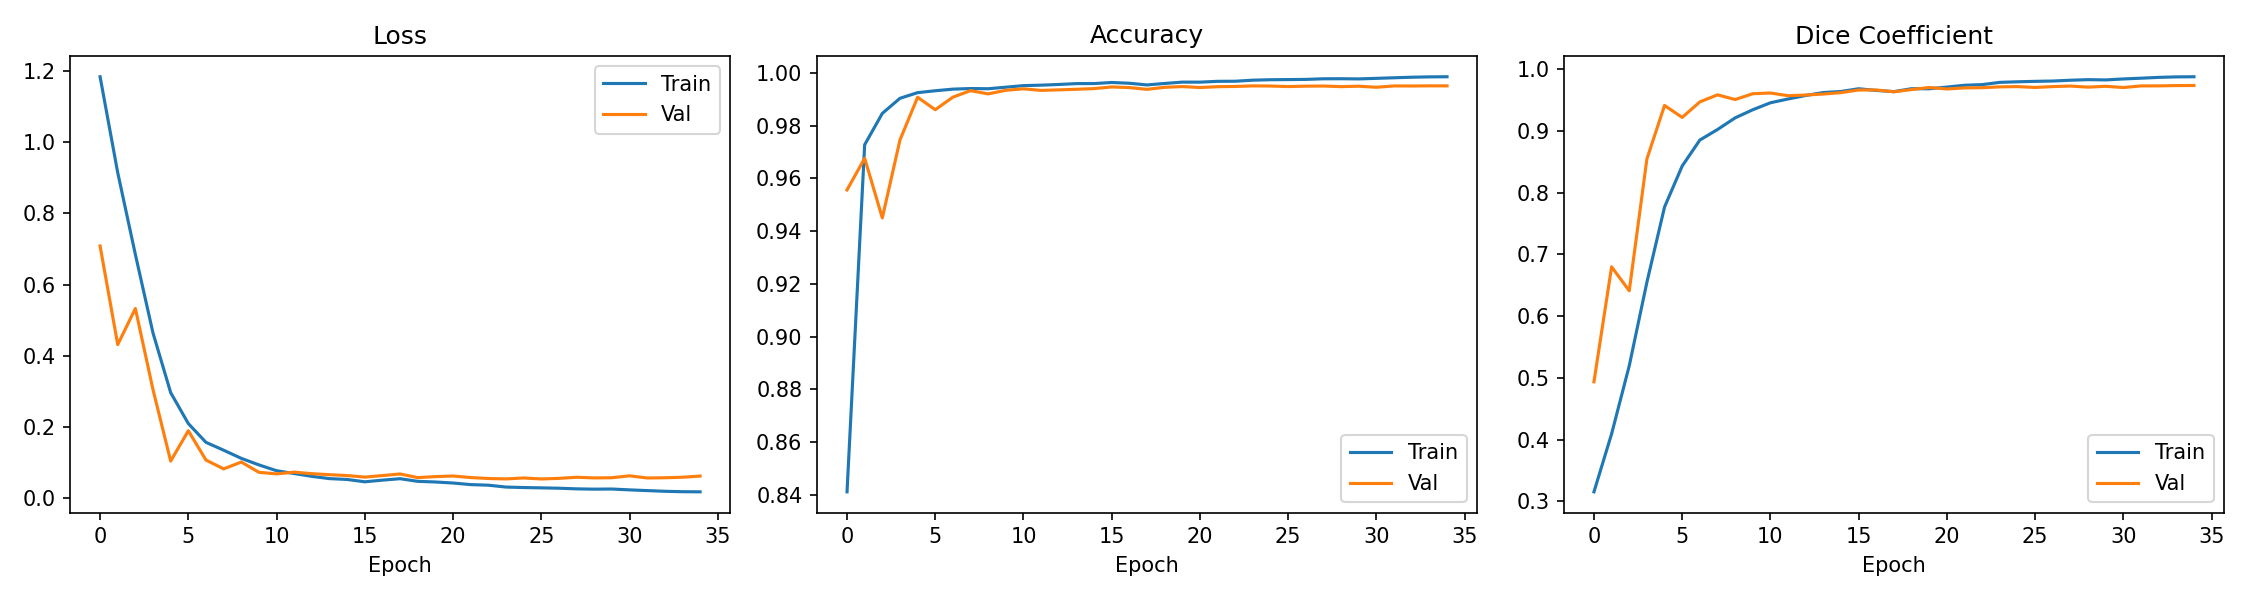

In [9]:
from IPython.display import Image as IPImage
IPImage(os.path.join(DRIVE_MODELS,'training_history.png'))

## Cell 9 — GEE & detection helpers
Run once to define all functions.

In [10]:
# ── GEE init ─────────────────────────────────────────────────────
def init_gee():
    try:
        ee.Initialize(project=GEE_PROJECT)
        print(f'[GEE] Initialized OK  (project={GEE_PROJECT})')
    except Exception as e:
        err=str(e)
        if 'PERMISSION_DENIED' in err or '403' in err:
            raise RuntimeError(
                f'403 PERMISSION DENIED for project "{GEE_PROJECT}".\n'
                f'Fix: console.cloud.google.com → APIs & Services\n'
                f'     → Enable "Earth Engine API" for your project.\n'
                f'OR:  Change GEE_PROJECT in Cell 4 to your own project ID.'
            ) from None
        elif 'authorize' in err.lower() or 'authenticate' in err.lower():
            raise RuntimeError('Run Cell 3 (ee.Authenticate()) first.') from None
        else:
            raise RuntimeError(f'GEE error: {err}') from None

# ── SAR download + Drive save ─────────────────────────────────────
def download_sar_and_save(area_id, area_name, bounds, start_date, end_date, season_label):
    """
    Download Sentinel-1 SAR data for one area+period.
    Saves raw .npy array and a preview PNG to Drive immediately.
    Returns (preprocessed_array, date_string) or (None, None).
    """
    geometry = ee.Geometry.Rectangle(bounds)
    col = (ee.ImageCollection('COPERNICUS/S1_GRD')
           .filterBounds(geometry).filterDate(start_date, end_date)
           .filter(ee.Filter.listContains('transmitterReceiverPolarisation','VV'))
           .filter(ee.Filter.listContains('transmitterReceiverPolarisation','VH'))
           .filter(ee.Filter.eq('instrumentMode','IW'))
           .select(['VV','VH']))
    count = col.size().getInfo()
    print(f'      {season_label}: {count} Sentinel-1 scenes found')
    if count == 0:
        return None, None
    image = col.median()
    ts    = col.sort('system:time_start',False).first().get('system:time_start').getInfo()
    date  = datetime.fromtimestamp(ts/1000).strftime('%Y-%m-%d')
    try:
        sample = image.sampleRectangle(region=geometry, defaultValue=-999).getInfo()
        vv = np.array(sample['properties']['VV'], dtype=np.float32)
        vh = np.array(sample['properties']['VH'], dtype=np.float32)
        vv[vv==-999]=np.nan; vh[vh==-999]=np.nan
        raw = np.stack([vv,vh],axis=-1)
        # ── save raw array to Drive ───────────────────────────
        raw_fname = f'{area_id}_{season_label}_{date}.npy'
        np.save(os.path.join(DRIVE_SAT_RAW, raw_fname), raw)
        print(f'      [DRIVE] Raw saved → satellite/raw/{raw_fname}')
        # ── save preview PNG to Drive ─────────────────────────
        vv_clean = np.nan_to_num(vv, nan=-15.0)
        vh_clean = np.nan_to_num(vh, nan=-15.0)
        fig, axes = plt.subplots(1,2,figsize=(10,4))
        fig.suptitle(f'{area_name}\n{season_label}  |  {date}', fontweight='bold')
        axes[0].imshow(vv_clean, cmap='gray', vmin=-25, vmax=-5)
        axes[0].set_title(f'VV band  ({vv_clean.shape[0]}x{vv_clean.shape[1]} px)')
        axes[0].axis('off')
        axes[1].imshow(vh_clean, cmap='gray', vmin=-30, vmax=-8)
        axes[1].set_title('VH band')
        axes[1].axis('off')
        plt.tight_layout()
        prev_fname = f'{area_id}_{season_label}_{date}.png'
        plt.savefig(os.path.join(DRIVE_SAT_PREV, prev_fname), dpi=100, bbox_inches='tight')
        plt.close()
        print(f'      [DRIVE] Preview saved → satellite/preview/{prev_fname}')
        # ── preprocess for model ──────────────────────────────
        h,w = raw.shape[:2]
        resized = zoom(np.nan_to_num(raw,nan=-15.0),(IMAGE_SIZE/h,IMAGE_SIZE/w,1),order=1)
        processed = np.clip((resized+SAR_SHIFT)/SAR_SHIFT,0,1).astype(np.float32)
        return processed, date
    except Exception as e:
        print(f'      [WARN] Download failed: {str(e)[:100]}')
        return None, None

# ── Change detection ──────────────────────────────────────────────
def detect_flood_change(model, ref_img, cur_img):
    ref_pred = model.predict(ref_img[np.newaxis],verbose=0)[0,:,:,0]
    cur_pred = model.predict(cur_img[np.newaxis],verbose=0)[0,:,:,0]
    ref_water=(ref_pred>0.5).astype(np.float32)
    cur_water=(cur_pred>0.5).astype(np.float32)
    return {'ref_water':ref_pred,'cur_water':cur_pred,
            'flood_mask':np.maximum(0.0,cur_water-ref_water),
            'vv_change':cur_img[:,:,0]-ref_img[:,:,0]}

def analyse(det):
    total=det['flood_mask'].size
    pct  =(det['flood_mask']>0.5).sum()/total*100
    perm =(det['ref_water'] >0.5).sum()/total*100
    cur  =(det['cur_water'] >0.5).sum()/total*100
    if   pct>25: status,risk='SEVERE FLOODING',     'CRITICAL'
    elif pct>15: status,risk='SIGNIFICANT FLOODING','HIGH'
    elif pct>8:  status,risk='MODERATE FLOODING',   'MEDIUM'
    elif pct>3:  status,risk='MINOR FLOODING',      'LOW'
    else:        status,risk='NO SIGNIFICANT FLOOD','MINIMAL'
    return {'flood_pct':pct,'perm_water_pct':perm,'cur_water_pct':cur,
            'status':status,'risk':risk}

# ── Result visualization ──────────────────────────────────────────
def visualize_and_save(area_name, ref_img, cur_img, det, ana,
                       ref_date, cur_date, area_id):
    fig,axes=plt.subplots(2,3,figsize=(15,10))
    fig.suptitle(f'Flood Detection: {area_name}\n'
                 f'Ref (dry): {ref_date}   →   Current (monsoon): {cur_date}',
                 fontsize=13,fontweight='bold')
    def db(n): return n*SAR_SHIFT-SAR_SHIFT
    axes[0,0].imshow(db(ref_img[:,:,0]),cmap='gray',vmin=-25,vmax=-5)
    axes[0,0].set_title(f'Reference VV (dry)\n{ref_date}'); axes[0,0].axis('off')
    axes[0,1].imshow(db(cur_img[:,:,0]),cmap='gray',vmin=-25,vmax=-5)
    axes[0,1].set_title(f'Current VV (monsoon)\n{cur_date}'); axes[0,1].axis('off')
    im3=axes[0,2].imshow(det['vv_change']*SAR_SHIFT,cmap='RdBu',vmin=-10,vmax=10)
    axes[0,2].set_title('SAR Change (dB)\nblue = water increase'); axes[0,2].axis('off')
    plt.colorbar(im3,ax=axes[0,2],fraction=0.046)
    axes[1,0].imshow(det['ref_water'],cmap='Blues',vmin=0,vmax=1)
    axes[1,0].set_title(f'Permanent water\n{ana["perm_water_pct"]:.1f}%'); axes[1,0].axis('off')
    axes[1,1].imshow(det['flood_mask'],cmap='Reds',vmin=0,vmax=1)
    axes[1,1].set_title(f'NEW flooding\n{ana["flood_pct"]:.1f}%'); axes[1,1].axis('off')
    axes[1,2].imshow(db(cur_img[:,:,0]),cmap='gray',vmin=-25,vmax=-5)
    overlay=np.ma.masked_where(det['flood_mask']<0.5,det['flood_mask'])
    axes[1,2].imshow(overlay,cmap='Reds',alpha=0.7)
    axes[1,2].contour(det['ref_water'],levels=[0.5],colors=['#1565C0'],linewidths=1)
    axes[1,2].set_title(f'{ana["status"]}\nRisk: {ana["risk"]}'); axes[1,2].axis('off')
    plt.tight_layout()
    # save to both local and Drive
    local_path = os.path.join(LOCAL_OUTPUT_DIR, f'{area_id}.png')
    drive_path = os.path.join(DRIVE_RESULTS,    f'{area_id}.png')
    plt.savefig(local_path, dpi=150, bbox_inches='tight')
    plt.savefig(drive_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'   [DRIVE] Result map → results/{area_id}.png')

print('All helpers defined. Ready for Cell 10.')

All helpers defined. Ready for Cell 10.


## Cell 10 — Run flood detection on all areas
Downloads real Sentinel-1 imagery from GEE for each area.
Raw satellite arrays and preview images are saved to Drive as they download.

> ⚠️ Make sure Cell 3 (GEE authentication) was run first.

In [16]:
# Clear any cached credentials first
import subprocess
subprocess.run(['rm', '-rf', '/root/.config/earthengine'], capture_output=True)

# Fresh authentication
import ee
from google.colab import auth
auth.authenticate_user()
ee.Initialize(project='my-project01-462820')
print(ee.String('Connected!').getInfo())

Connected!


In [17]:
def detect_all():
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f'Model not found: {MODEL_PATH} — run Cell 8 first.')
    print('[MODEL] Loading...')
    model = keras.models.load_model(MODEL_PATH, custom_objects=CUSTOM_OBJECTS)
    print('        Loaded OK')
    init_gee()
    print(f'\n[DATES] Reference (dry season) : {REF_START} → {REF_END}')
    print(f'[DATES] Current  (monsoon)      : {CUR_START} → {CUR_END}')
    os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)
    results=[]
    print('\n'+'='*60+'\n  SCANNING AREAS\n'+'='*60)
    for area_id, info in FLOOD_PRONE_AREAS.items():
        print(f'\n[AREA] {info["name"]}')
        print('   Downloading reference (dry season)...')
        ref_p, ref_date = download_sar_and_save(
            area_id, info['name'], info['bounds'], REF_START, REF_END, 'dry')
        if ref_p is None: print('   [SKIP] No reference data'); continue
        time.sleep(0.5)
        print('   Downloading current (monsoon)...')
        cur_p, cur_date = download_sar_and_save(
            area_id, info['name'], info['bounds'], CUR_START, CUR_END, 'monsoon')
        if cur_p is None: print('   [SKIP] No monsoon data'); continue
        time.sleep(0.5)
        print('   Running flood detection...')
        det = detect_flood_change(model, ref_p, cur_p)
        ana = analyse(det)
        print(f'   Status : {ana["status"]}')
        print(f'   Flood  : {ana["flood_pct"]:.1f}%   Risk: {ana["risk"]}')
        visualize_and_save(info['name'],ref_p,cur_p,det,ana,
                           ref_date,cur_date,area_id)
        results.append({'area':info['name'],
                        'flood_pct':round(ana['flood_pct'],2),
                        'risk':ana['risk'],'status':ana['status'],
                        'ref_date':ref_date,'cur_date':cur_date})
    # summary
    print('\n'+'='*60+'\n  SUMMARY\n'+'='*60)
    print(f'{"Area":<38} {"Flood %":>8}   Risk')
    print('-'*60)
    for r in results:
        print(f'{r["area"]:<38} {r["flood_pct"]:>7.1f}%   {r["risk"]}')
    # save summary JSON to Drive
    summary_path = os.path.join(DRIVE_RESULTS,'summary.json')
    with open(summary_path,'w') as f: json.dump(results,f,indent=2)
    print(f'\n[DRIVE] Summary → results/summary.json')
    print(f'[DONE]  All results saved to {DRIVE_RESULTS}/')
    return results

results = detect_all()

[MODEL] Loading...
        Loaded OK
[GEE] Initialized OK  (project=my-project01-462820)

[DATES] Reference (dry season) : 2024-01-01 → 2024-03-31
[DATES] Current  (monsoon)      : 2024-06-01 → 2024-09-30

  SCANNING AREAS

[AREA] Sylhet — Surma River Basin
      dry: 16 Sentinel-1 scenes found
      [DRIVE] Raw saved → satellite/raw/sylhet_surma_river_dry_2024-03-27.npy
      [DRIVE] Preview saved → satellite/preview/sylhet_surma_river_dry_2024-03-27.png
      monsoon: 17 Sentinel-1 scenes found
      [DRIVE] Raw saved → satellite/raw/sylhet_surma_river_monsoon_2024-09-23.npy
      [DRIVE] Preview saved → satellite/preview/sylhet_surma_river_monsoon_2024-09-23.png
   Running flood detection...
   Status : NO SIGNIFICANT FLOOD
   Flood  : 0.8%   Risk: MINIMAL
   [DRIVE] Result map → results/sylhet_surma_river.png

[AREA] Sunamganj Haor Region
      dry: 36 Sentinel-1 scenes found
      [DRIVE] Raw saved → satellite/raw/sunamganj_haor_dry_2024-03-30.npy
      [DRIVE] Preview saved → sat

## Cell 11 — View detection maps inline


── Sylhet — Surma River Basin ──


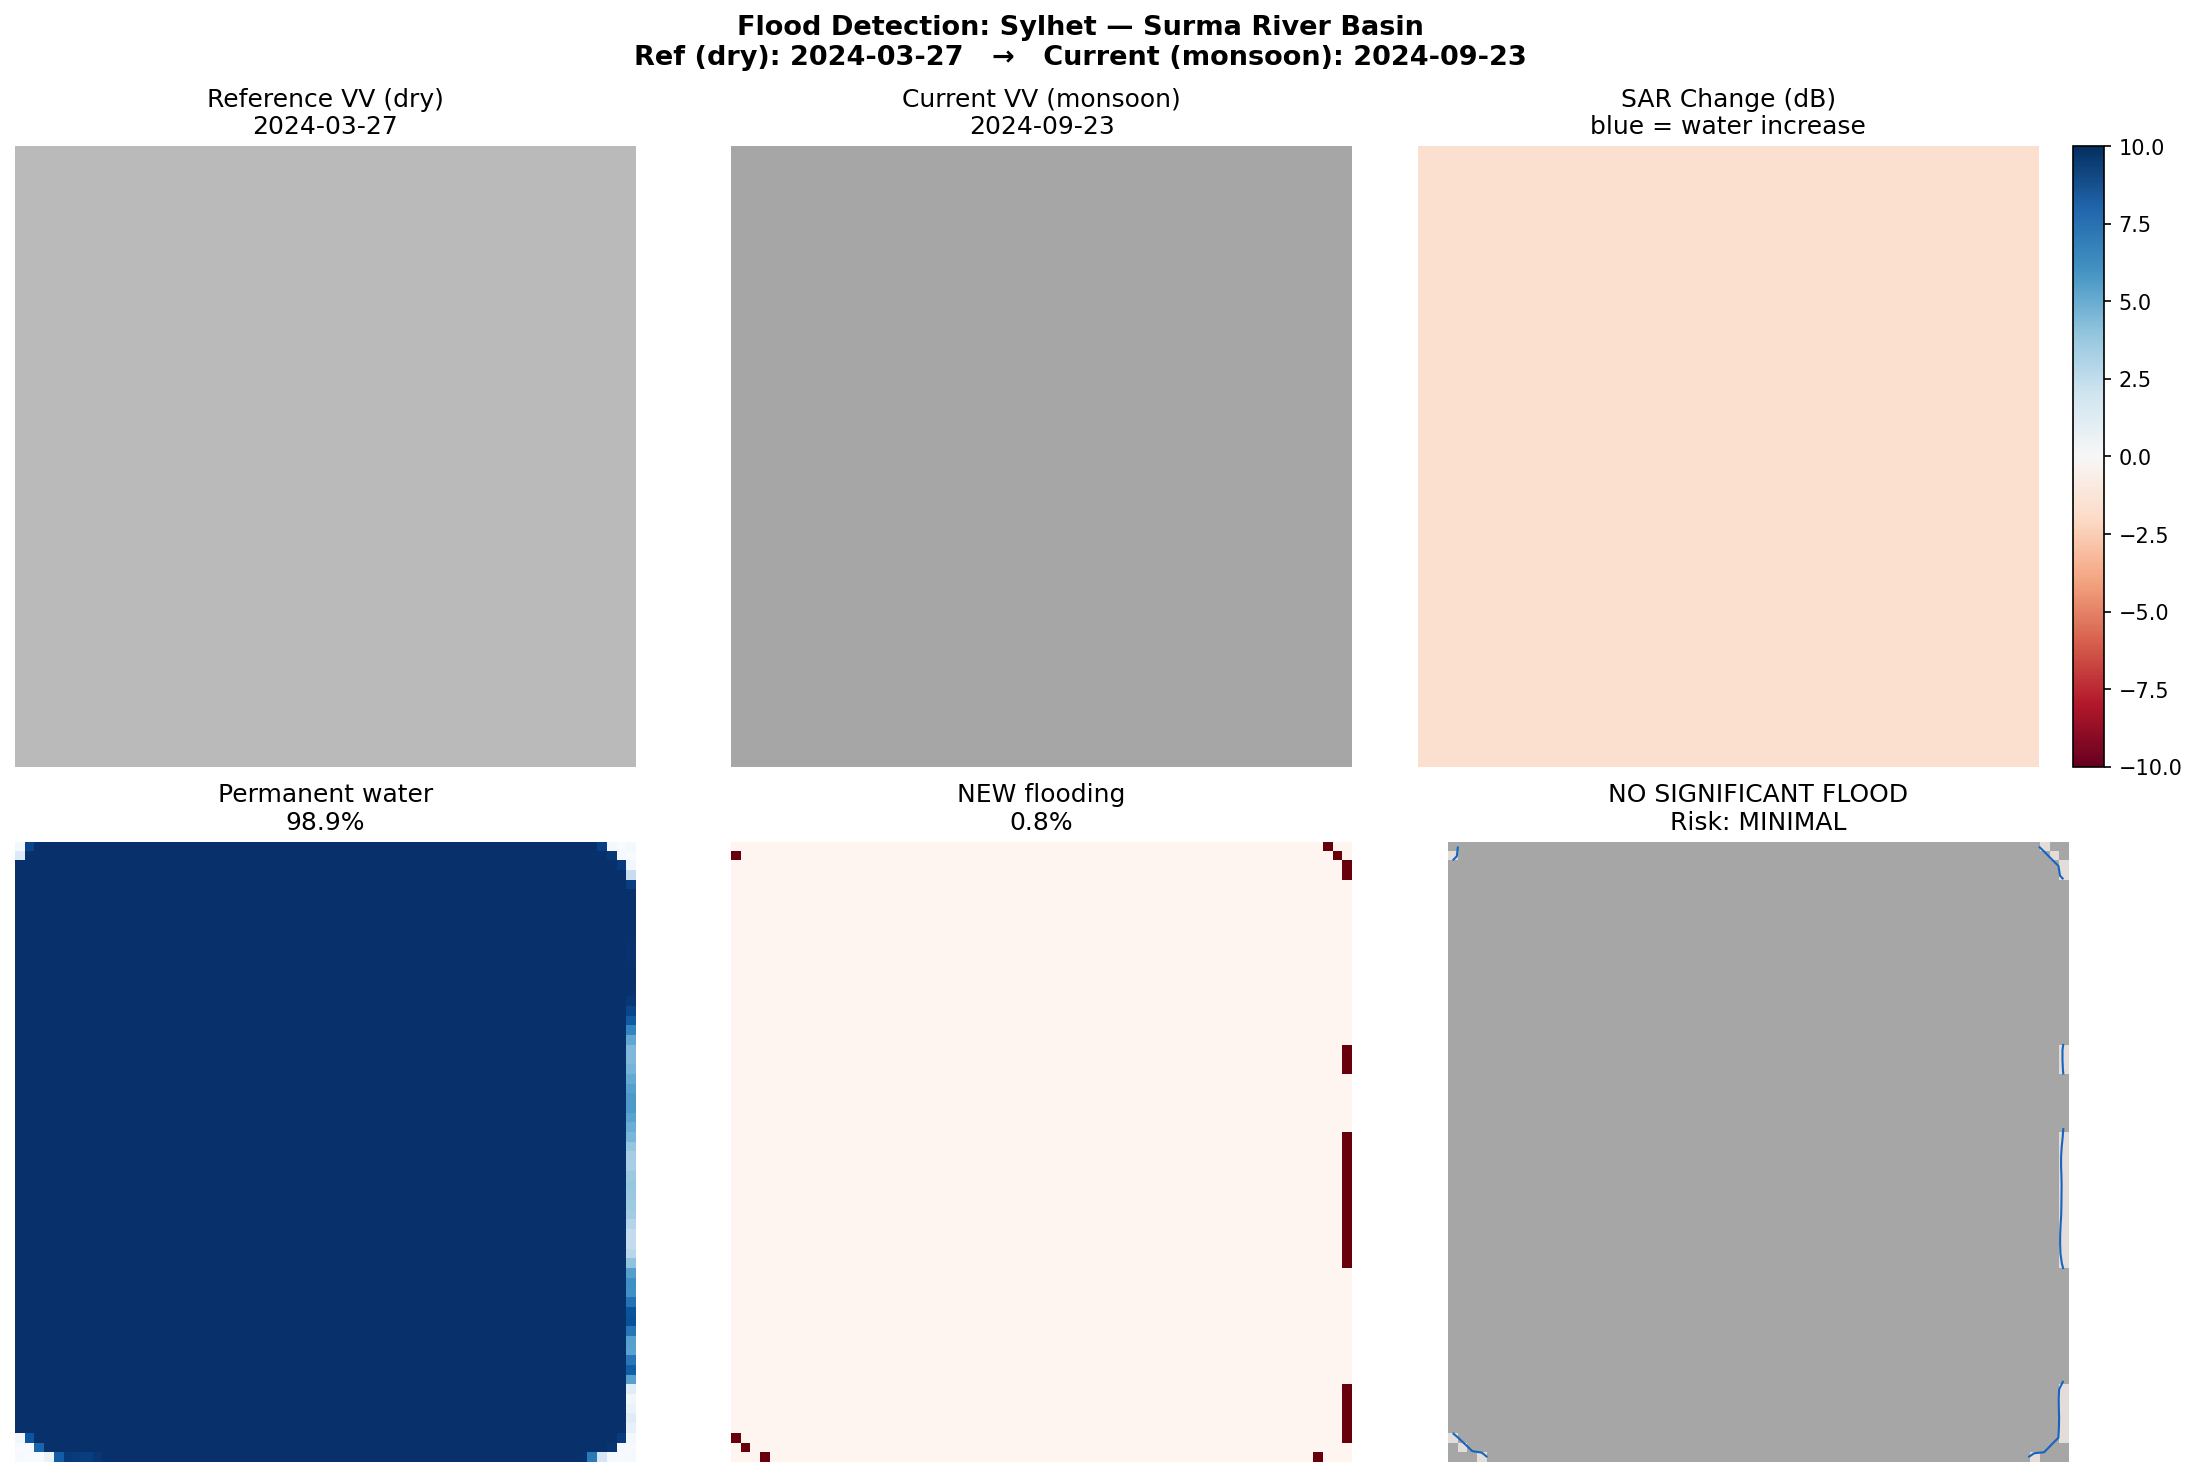


── Sunamganj Haor Region ──


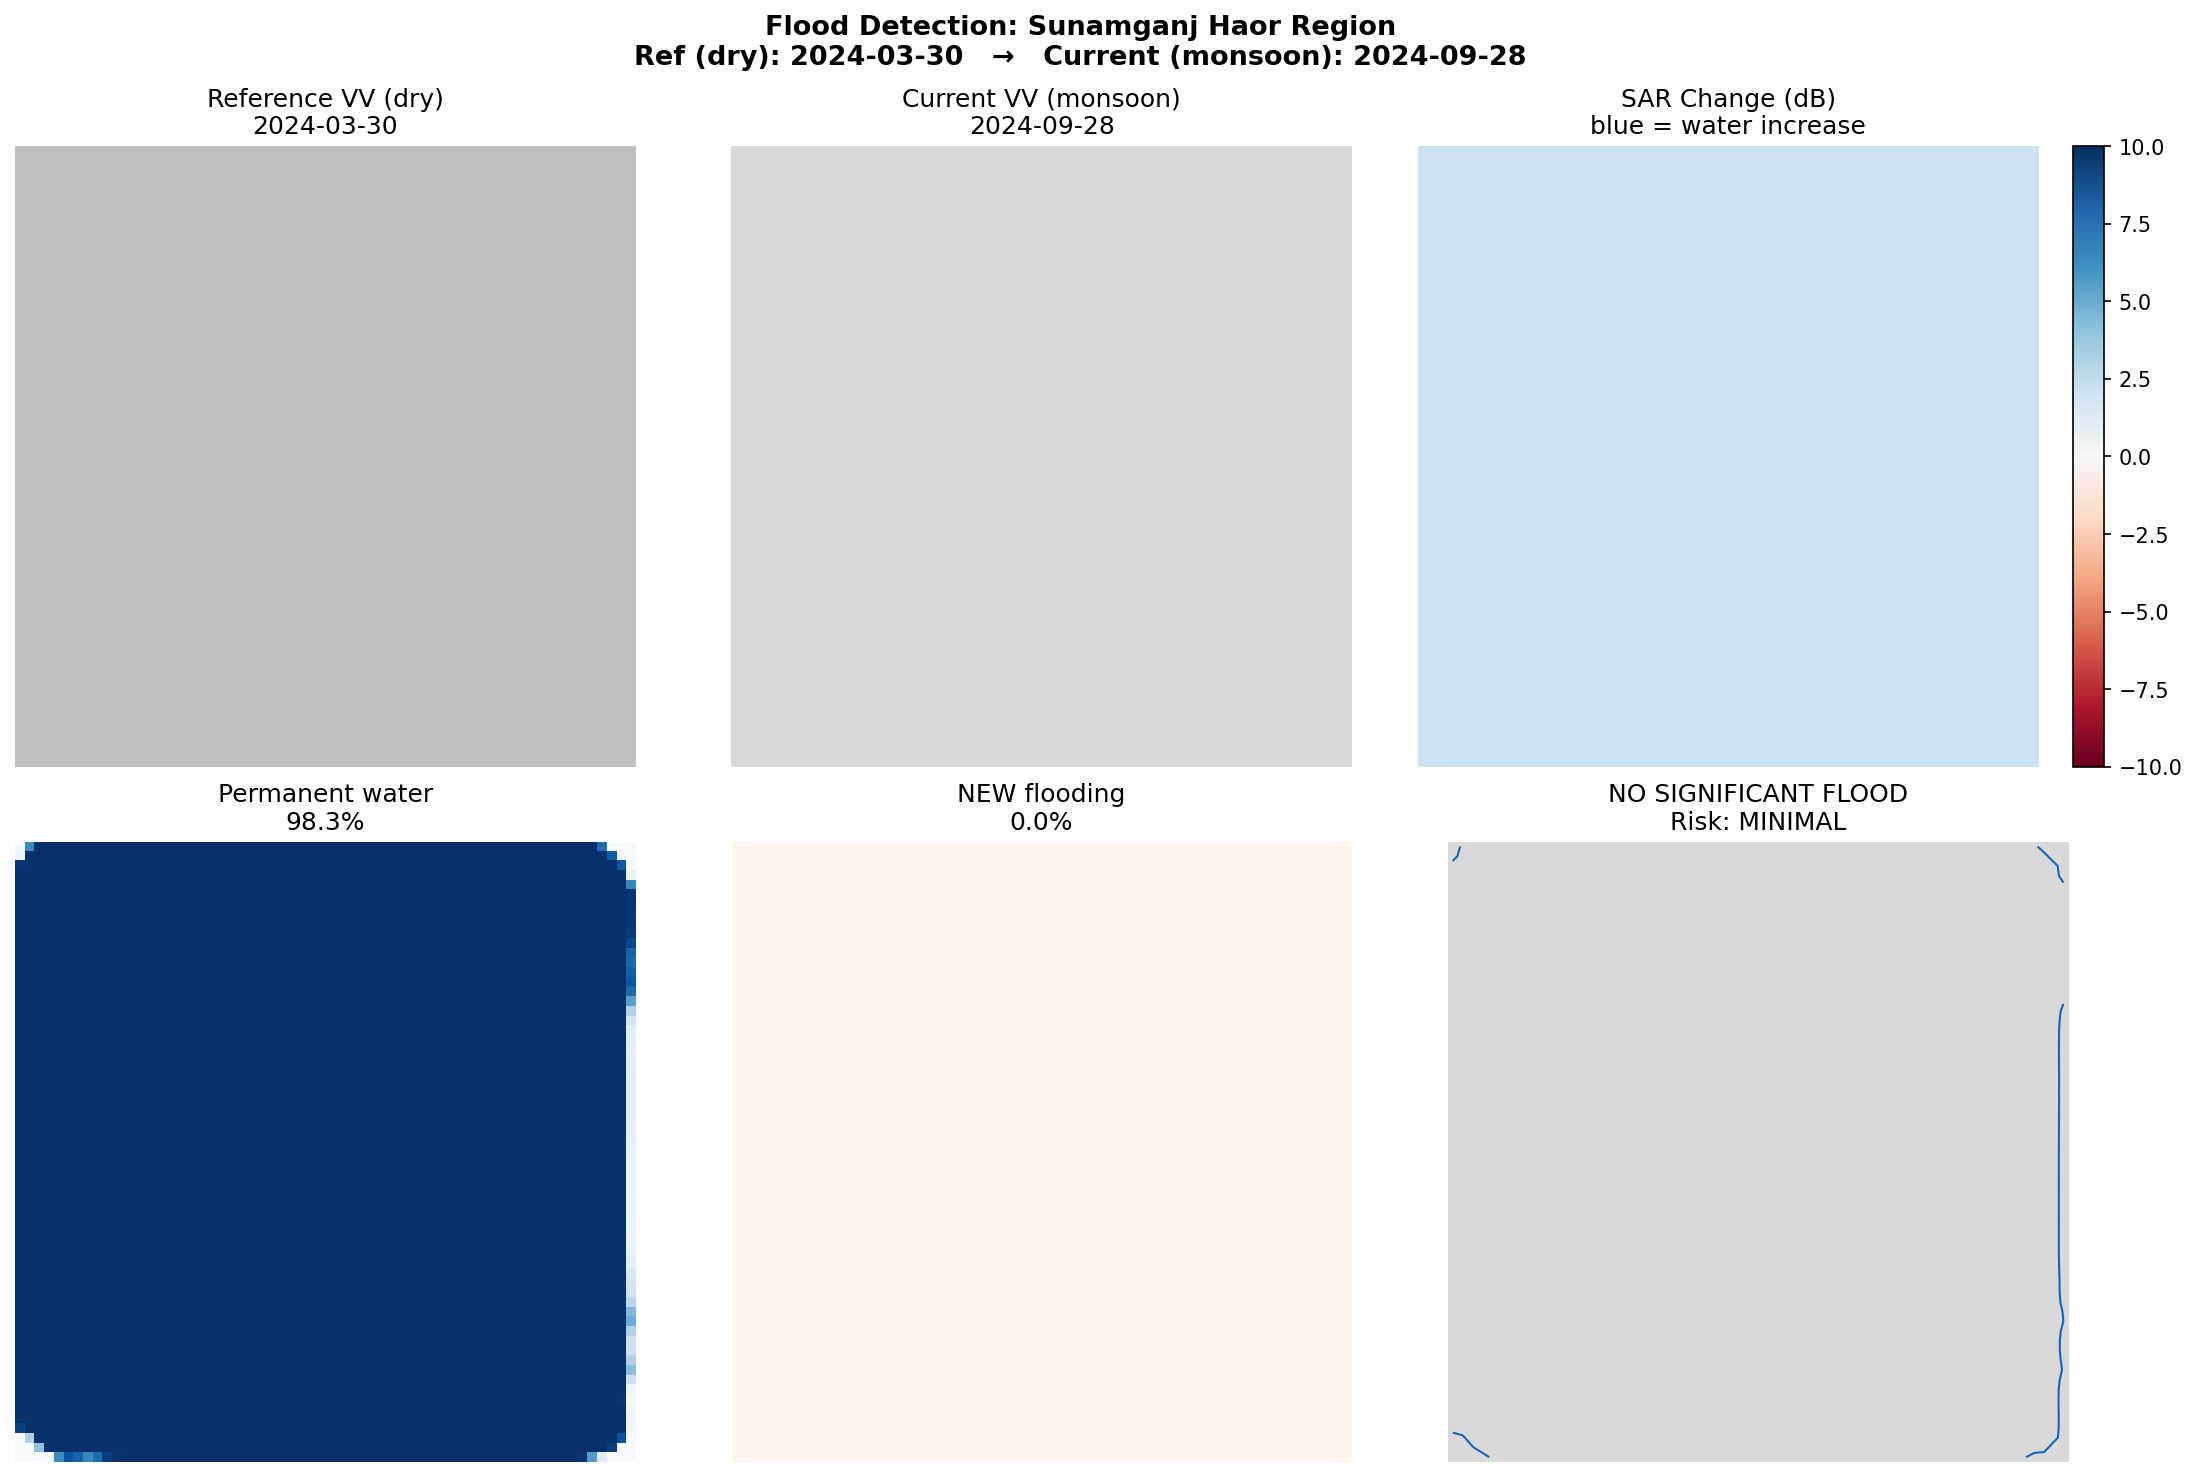


── Sirajganj — Jamuna River ──


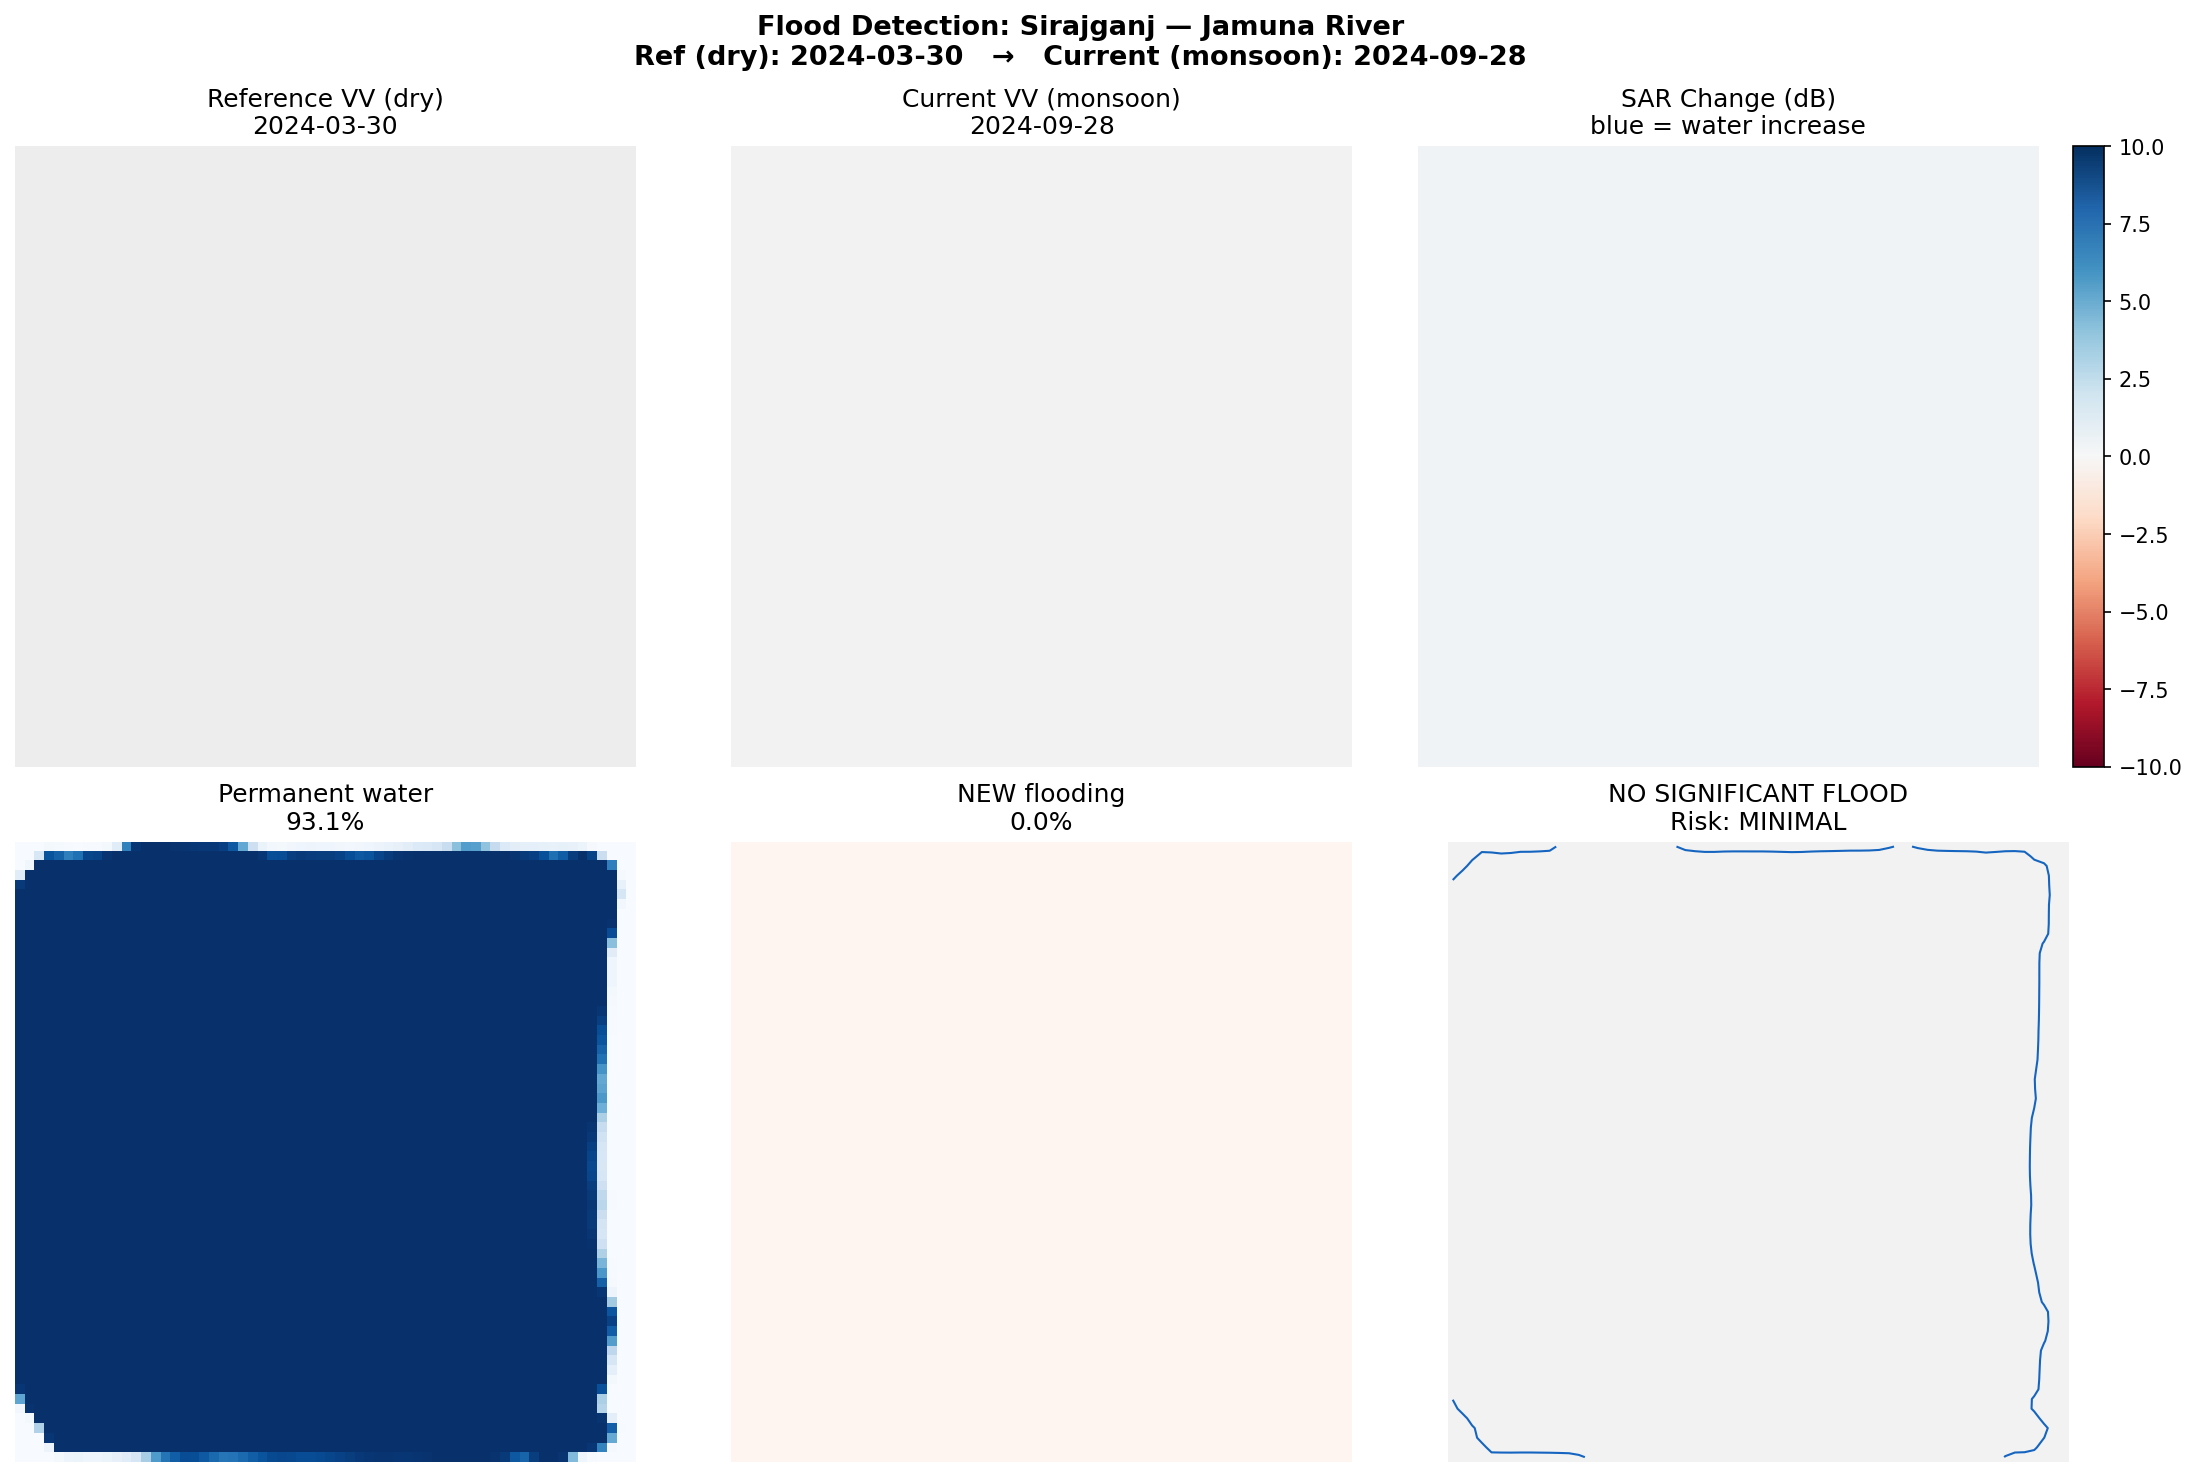


── Kurigram — Brahmaputra Basin ──


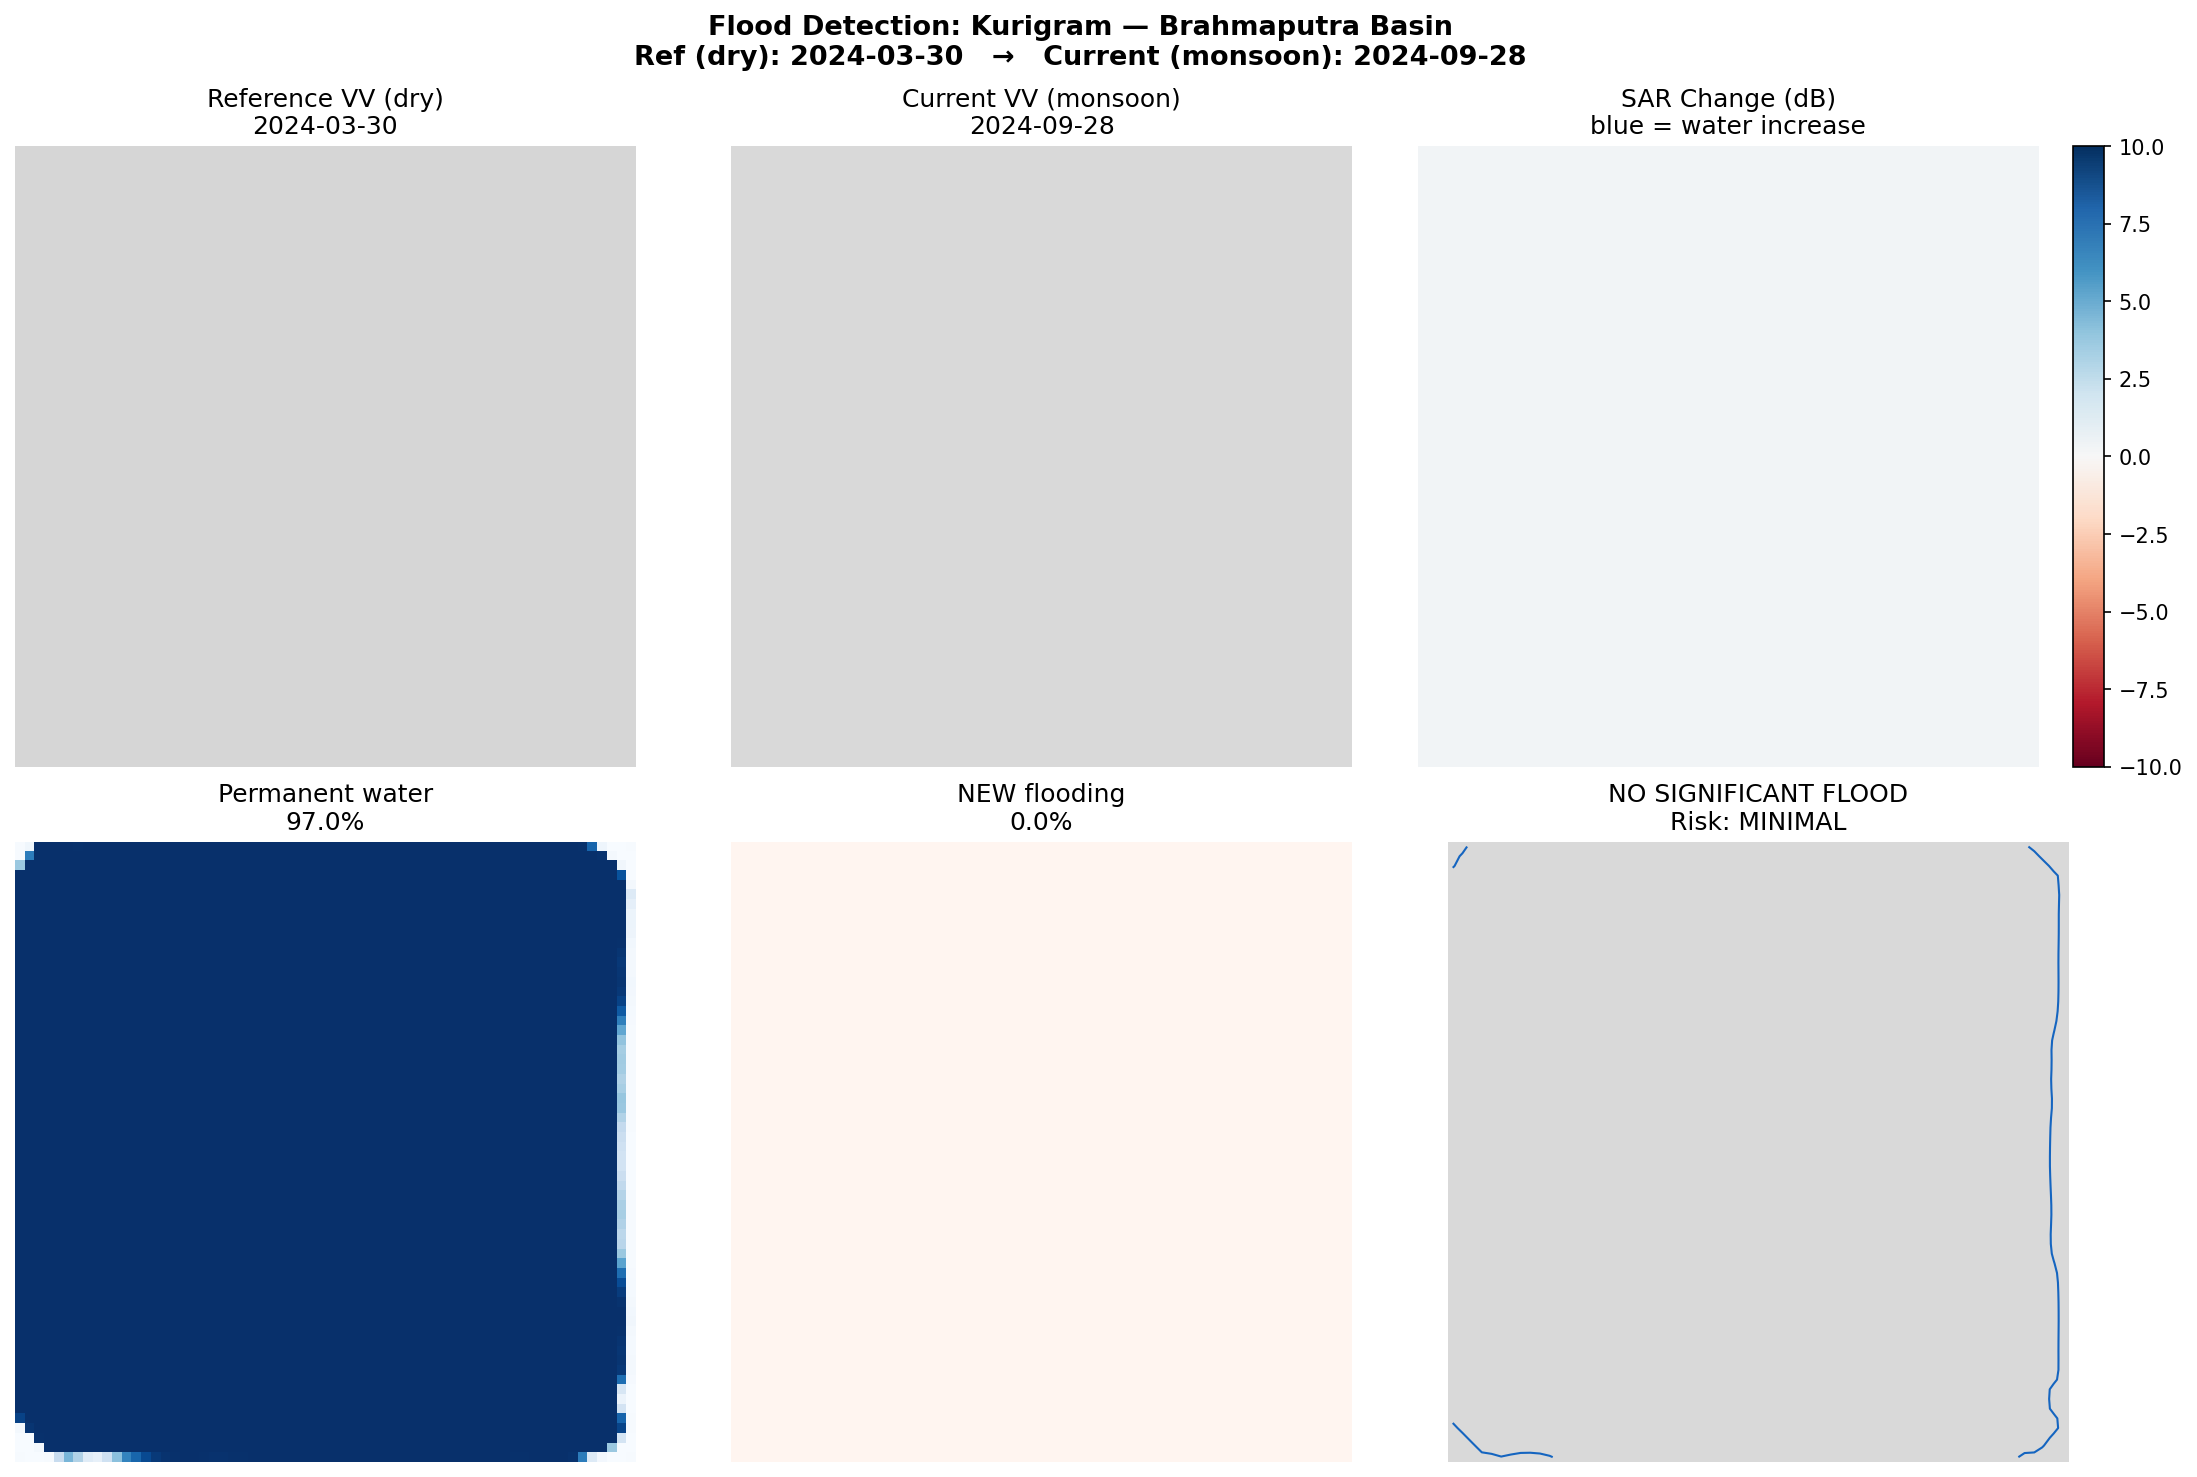


── Chandpur — River Confluence ──


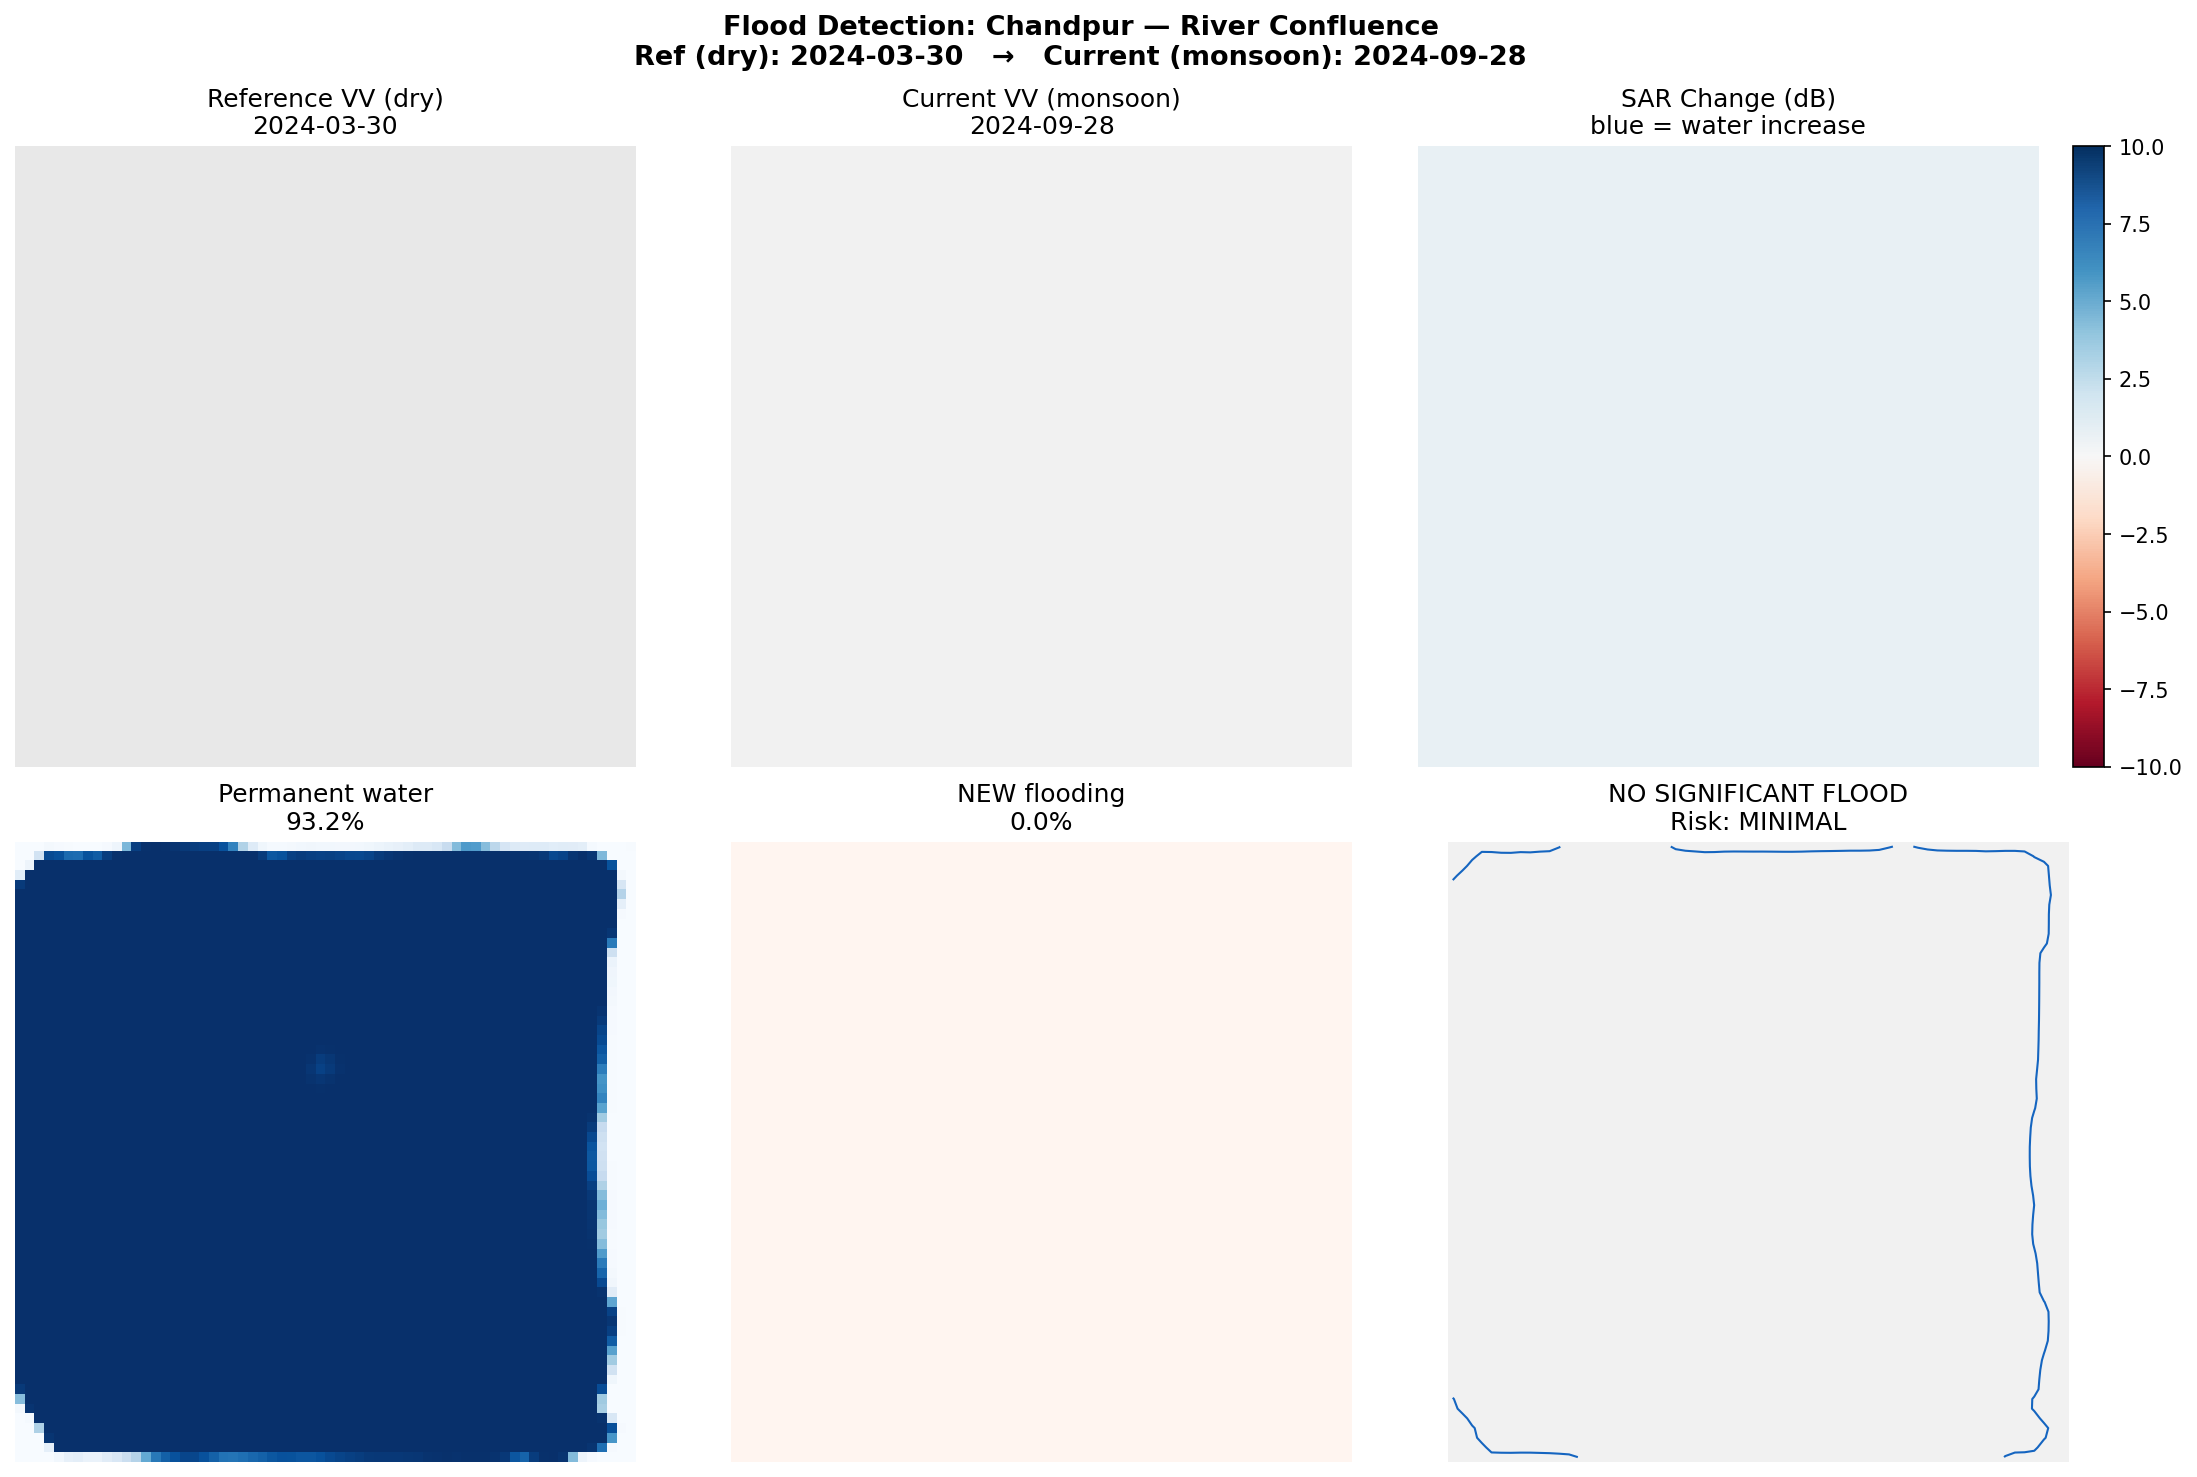

In [18]:
from IPython.display import Image as IPImage, display

for area_id, info in FLOOD_PRONE_AREAS.items():
    path = os.path.join(DRIVE_RESULTS, f'{area_id}.png')
    if os.path.exists(path):
        print(f'\n── {info["name"]} ──')
        display(IPImage(path))
    else:
        print(f'No result found for {area_id} — run Cell 10 first.')

## Cell 12 — Summary table

In [19]:
summary_path = os.path.join(DRIVE_RESULTS,'summary.json')
if os.path.exists(summary_path):
    with open(summary_path) as f: summary=json.load(f)
    print(f'\n{"Area":<38} {"Flood%":>7}   {"Risk":<10}   Status')
    print('='*80)
    for r in summary:
        print(f'{r["area"]:<38} {r["flood_pct"]:>6.1f}%   {r["risk"]:<10}   {r["status"]}')
else:
    print('No summary yet — run Cell 10.')


Area                                    Flood%   Risk         Status
Sylhet — Surma River Basin                0.8%   MINIMAL      NO SIGNIFICANT FLOOD
Sunamganj Haor Region                     0.0%   MINIMAL      NO SIGNIFICANT FLOOD
Sirajganj — Jamuna River                  0.0%   MINIMAL      NO SIGNIFICANT FLOOD
Kurigram — Brahmaputra Basin              0.0%   MINIMAL      NO SIGNIFICANT FLOOD
Chandpur — River Confluence               0.0%   MINIMAL      NO SIGNIFICANT FLOOD


## Cell 13 — Confusion Matrix & Full Evaluation Metrics
Runs the trained model on a held-out test set (synthetic data) and produces:

- **Confusion matrix** — TP, FP, TN, FN pixel counts
- **Precision, Recall, F1-score**
- **IoU (Jaccard Index)**
- **Dice coefficient**
- **Accuracy**
- **ROC curve + AUC score**
- Full report saved to Drive → `FloodDetection/evaluation/`

> The confusion matrix treats every **pixel** as an individual prediction:
> - **TP** = model said flood, label says flood
> - **FP** = model said flood, label says no flood (false alarm)
> - **TN** = model said no flood, label says no flood
> - **FN** = model said no flood, label says flood (missed flood)

In [20]:
import itertools
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

# ── Step 1: generate a fresh test set (never seen during training) ──
print('[TEST] Generating 200 test samples...')
np.random.seed(42)   # fixed seed so test set is reproducible
X_test, y_test = generate_and_save_training_data.__wrapped__(200) \
    if hasattr(generate_and_save_training_data,'__wrapped__') \
    else None, None

# Generate fresh test data inline (avoids Drive re-save)
def make_test_data(n=200):
    print(f'  Generating {n} test samples (not saved to Drive)...')
    size = IMAGE_SIZE
    images, masks = [], []
    params = {'urban':(-6,-12,2.5),'vegetation':(-10,-16,3.0),
              'bare':(-12,-18,2.0),'mixed':(-9,-15,3.5)}
    for i in range(n):
        img  = np.zeros((size,size,2), dtype=np.float32)
        mask = np.zeros((size,size,1), dtype=np.float32)
        bvv,bvh,ns = params[np.random.choice(list(params))]
        spk = np.random.gamma(4,0.25,(size,size))
        img[:,:,0] = gaussian_filter(np.random.normal(bvv,ns,(size,size)),sigma=1.5)*spk
        img[:,:,1] = gaussian_filter(np.random.normal(bvh,ns,(size,size)),sigma=1.5)*spk
        if np.random.random()>0.65:
            ry,rw=np.random.randint(10,size-10),np.random.randint(2,5)
            for x in range(size):
                yo=int(4*np.sin(x/8.0))
                ys,ye=max(0,ry+yo-rw),min(size,ry+yo+rw)
                img[ys:ye,x,0]=np.random.uniform(-23,-19)
                img[ys:ye,x,1]=np.random.uniform(-29,-25)
        if np.random.random()>0.5:
            for _ in range(np.random.randint(1,4)):
                cx=np.random.randint(10,size-10)
                cy=np.random.randint(10,size-10)
                br=np.random.randint(5,18)
                yg,xg=np.ogrid[:size,:size]
                dist=np.sqrt((xg-cx)**2+(yg-cy)**2)
                ang=np.arctan2(yg-cy,xg-cx)
                eff_r=br+np.sin(ang*np.random.randint(3,7))*np.random.uniform(2,4)
                soft=np.clip((eff_r-dist)/2.0,0,1)
                wn=np.random.normal(0,1.5,(size,size))
                img[:,:,0]=img[:,:,0]*(1-soft)+(np.random.uniform(-24,-18)+wn)*soft
                img[:,:,1]=img[:,:,1]*(1-soft)+(np.random.uniform(-30,-24)+wn)*soft
                mask[:,:,0]=np.maximum(mask[:,:,0],(dist<eff_r).astype(np.float32))
        img=np.clip((img+SAR_SHIFT)/SAR_SHIFT,0,1).astype(np.float32)
        img=np.clip(img+np.random.normal(0,0.02,img.shape).astype(np.float32),0,1)
        images.append(img); masks.append(mask.astype(np.float32))
    return np.array(images), np.array(masks)

X_test, y_test = make_test_data(200)
print(f'  Test set: {X_test.shape}  flood%: {y_test.mean()*100:.1f}')

# ── Step 2: get model predictions ───────────────────────────────
print('\n[PREDICT] Running model on test set...')
model_eval = keras.models.load_model(MODEL_PATH, custom_objects=CUSTOM_OBJECTS)
y_prob = model_eval.predict(X_test, batch_size=32, verbose=1)  # shape (N,64,64,1)

# Flatten to 1D pixel arrays
y_true_flat = y_test.flatten().astype(np.int32)        # ground truth: 0 or 1
y_prob_flat = y_prob.flatten()                          # predicted probability 0-1
y_pred_flat = (y_prob_flat > 0.5).astype(np.int32)     # binary prediction

print(f'  Total pixels evaluated : {len(y_true_flat):,}')
print(f'  Flood pixels (actual)  : {y_true_flat.sum():,}  ({y_true_flat.mean()*100:.1f}%)')
print(f'  Flood pixels (predicted): {y_pred_flat.sum():,}  ({y_pred_flat.mean()*100:.1f}%)')

# ── Step 3: compute confusion matrix ────────────────────────────
cm = confusion_matrix(y_true_flat, y_pred_flat)
TN, FP, FN, TP = cm.ravel()

print('\n' + '='*50)
print('  CONFUSION MATRIX (pixel level)')
print('='*50)
print(f'  TP (flood correctly detected) : {TP:>10,}')
print(f'  FP (false alarm — not flood)  : {FP:>10,}')
print(f'  TN (correctly no flood)       : {TN:>10,}')
print(f'  FN (missed flood)             : {FN:>10,}')

# ── Step 4: derived metrics ──────────────────────────────────────
precision  = TP / (TP + FP + 1e-9)
recall     = TP / (TP + FN + 1e-9)   # = sensitivity
specificity= TN / (TN + FP + 1e-9)
f1         = 2*precision*recall / (precision + recall + 1e-9)
accuracy   = (TP + TN) / (TP + TN + FP + FN)
iou        = TP / (TP + FP + FN + 1e-9)
dice       = 2*TP / (2*TP + FP + FN + 1e-9)

print('\n' + '='*50)
print('  EVALUATION METRICS')
print('='*50)
print(f'  Accuracy    : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision   : {precision:.4f}  (of all flood predictions, how many correct)')
print(f'  Recall      : {recall:.4f}  (of all real floods, how many detected)')
print(f'  Specificity : {specificity:.4f}  (of all non-flood, how many correctly skipped)')
print(f'  F1 Score    : {f1:.4f}')
print(f'  IoU         : {iou:.4f}  (Jaccard Index)')
print(f'  Dice Coeff  : {dice:.4f}')

# ── Step 5: plot confusion matrix ───────────────────────────────
os.makedirs(os.path.join(DRIVE_BASE,'evaluation'), exist_ok=True)
DRIVE_EVAL = os.path.join(DRIVE_BASE,'evaluation')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Flood Detection — Model Evaluation', fontsize=14, fontweight='bold')

# — Confusion matrix heatmap —
ax = axes[0]
cm_display = np.array([[TN, FP],[FN, TP]])
cm_pct     = cm_display / cm_display.sum() * 100
im = ax.imshow(cm_display, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix\n(pixel counts)', fontsize=12, fontweight='bold')
labels = [['TN\n(correct no-flood)', 'FP\n(false alarm)'],
          ['FN\n(missed flood)',      'TP\n(correct flood)']]
thresh = cm_display.max() / 2.0
for i,j in itertools.product(range(2),range(2)):
    color = 'white' if cm_display[i,j] > thresh else 'black'
    ax.text(j, i,
            f'{labels[i][j]}\n{cm_display[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
            ha='center', va='center', color=color, fontsize=9)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Predicted\nNo Flood','Predicted\nFlood'])
ax.set_yticklabels(['Actual\nNo Flood','Actual\nFlood'])
ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
plt.colorbar(im, ax=ax, fraction=0.046)

# — ROC curve —
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_true_flat, y_prob_flat)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#1565C0', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax2.plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random classifier')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
ax2.set_xlabel('False Positive Rate (1 - Specificity)')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title(f'ROC Curve\nAUC = {roc_auc:.4f}', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# — Precision-Recall curve —
ax3 = axes[2]
prec_curve, rec_curve, _ = precision_recall_curve(y_true_flat, y_prob_flat)
pr_auc = auc(rec_curve, prec_curve)
ax3.plot(rec_curve, prec_curve, color='#C62828', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
ax3.fill_between(rec_curve, prec_curve, alpha=0.1, color='#C62828')
ax3.axhline(y=y_true_flat.mean(), color='gray', lw=1, linestyle='--',
            label=f'Baseline (flood rate={y_true_flat.mean():.2f})')
ax3.set_xlim([0,1]); ax3.set_ylim([0,1.02])
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title(f'Precision-Recall Curve\nAUC = {pr_auc:.4f}', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
eval_plot_path = os.path.join(DRIVE_EVAL, 'confusion_matrix_and_curves.png')
plt.savefig(eval_plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'\n[DRIVE] Evaluation plot → evaluation/confusion_matrix_and_curves.png')

# ── Step 6: save full metrics report to Drive ────────────────────
report_txt = classification_report(y_true_flat, y_pred_flat,
                                    target_names=['No Flood','Flood'])
metrics_dict = {
    'accuracy':    round(float(accuracy),  6),
    'precision':   round(float(precision), 6),
    'recall':      round(float(recall),    6),
    'specificity': round(float(specificity),6),
    'f1_score':    round(float(f1),        6),
    'iou':         round(float(iou),       6),
    'dice_coef':   round(float(dice),      6),
    'roc_auc':     round(float(roc_auc),   6),
    'pr_auc':      round(float(pr_auc),    6),
    'confusion_matrix': {'TP':int(TP),'FP':int(FP),'TN':int(TN),'FN':int(FN)},
    'total_pixels_evaluated': int(len(y_true_flat)),
    'test_samples': 200,
}
json_path = os.path.join(DRIVE_EVAL, 'metrics.json')
with open(json_path,'w') as f: json.dump(metrics_dict, f, indent=2)
txt_path  = os.path.join(DRIVE_EVAL, 'classification_report.txt')
with open(txt_path,'w') as f:
    f.write('FLOOD DETECTION — FULL EVALUATION REPORT\n')
    f.write('='*50+'\n\n')
    f.write(f'Accuracy    : {accuracy:.4f}\n')
    f.write(f'Precision   : {precision:.4f}\n')
    f.write(f'Recall      : {recall:.4f}\n')
    f.write(f'Specificity : {specificity:.4f}\n')
    f.write(f'F1 Score    : {f1:.4f}\n')
    f.write(f'IoU         : {iou:.4f}\n')
    f.write(f'Dice Coeff  : {dice:.4f}\n')
    f.write(f'ROC AUC     : {roc_auc:.4f}\n')
    f.write(f'PR  AUC     : {pr_auc:.4f}\n\n')
    f.write('Confusion Matrix:\n')
    f.write(f'  TP={TP:,}  FP={FP:,}  TN={TN:,}  FN={FN:,}\n\n')
    f.write('Classification Report:\n')
    f.write(report_txt)
print(f'[DRIVE] Metrics JSON  → evaluation/metrics.json')
print(f'[DRIVE] Text report   → evaluation/classification_report.txt')
print('\n[DONE] Evaluation complete.')

[TEST] Generating 200 test samples...
  Generating 200 test samples (not saved to Drive)...
  Test set: (200, 64, 64, 2)  flood%: 10.4

[PREDICT] Running model on test set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 315ms/step
  Total pixels evaluated : 819,200
  Flood pixels (actual)  : 85,119  (10.4%)
  Flood pixels (predicted): 85,819  (10.5%)

  CONFUSION MATRIX (pixel level)
  TP (flood correctly detected) :     83,232
  FP (false alarm — not flood)  :      2,587
  TN (correctly no flood)       :    731,494
  FN (missed flood)             :      1,887

  EVALUATION METRICS
  Accuracy    : 0.9945  (99.45%)
  Precision   : 0.9699  (of all flood predictions, how many correct)
  Recall      : 0.9778  (of all real floods, how many detected)
  Specificity : 0.9965  (of all non-flood, how many correctly skipped)
  F1 Score    : 0.9738
  IoU         : 0.9490  (Jaccard Index)
  Dice Coeff  : 0.9738

[DRIVE] Evaluation plot → evaluation/confusion_matrix_and_curves.png
[DRIVE] Metrics JSON  → evaluation/

### View confusion matrix & curves inline

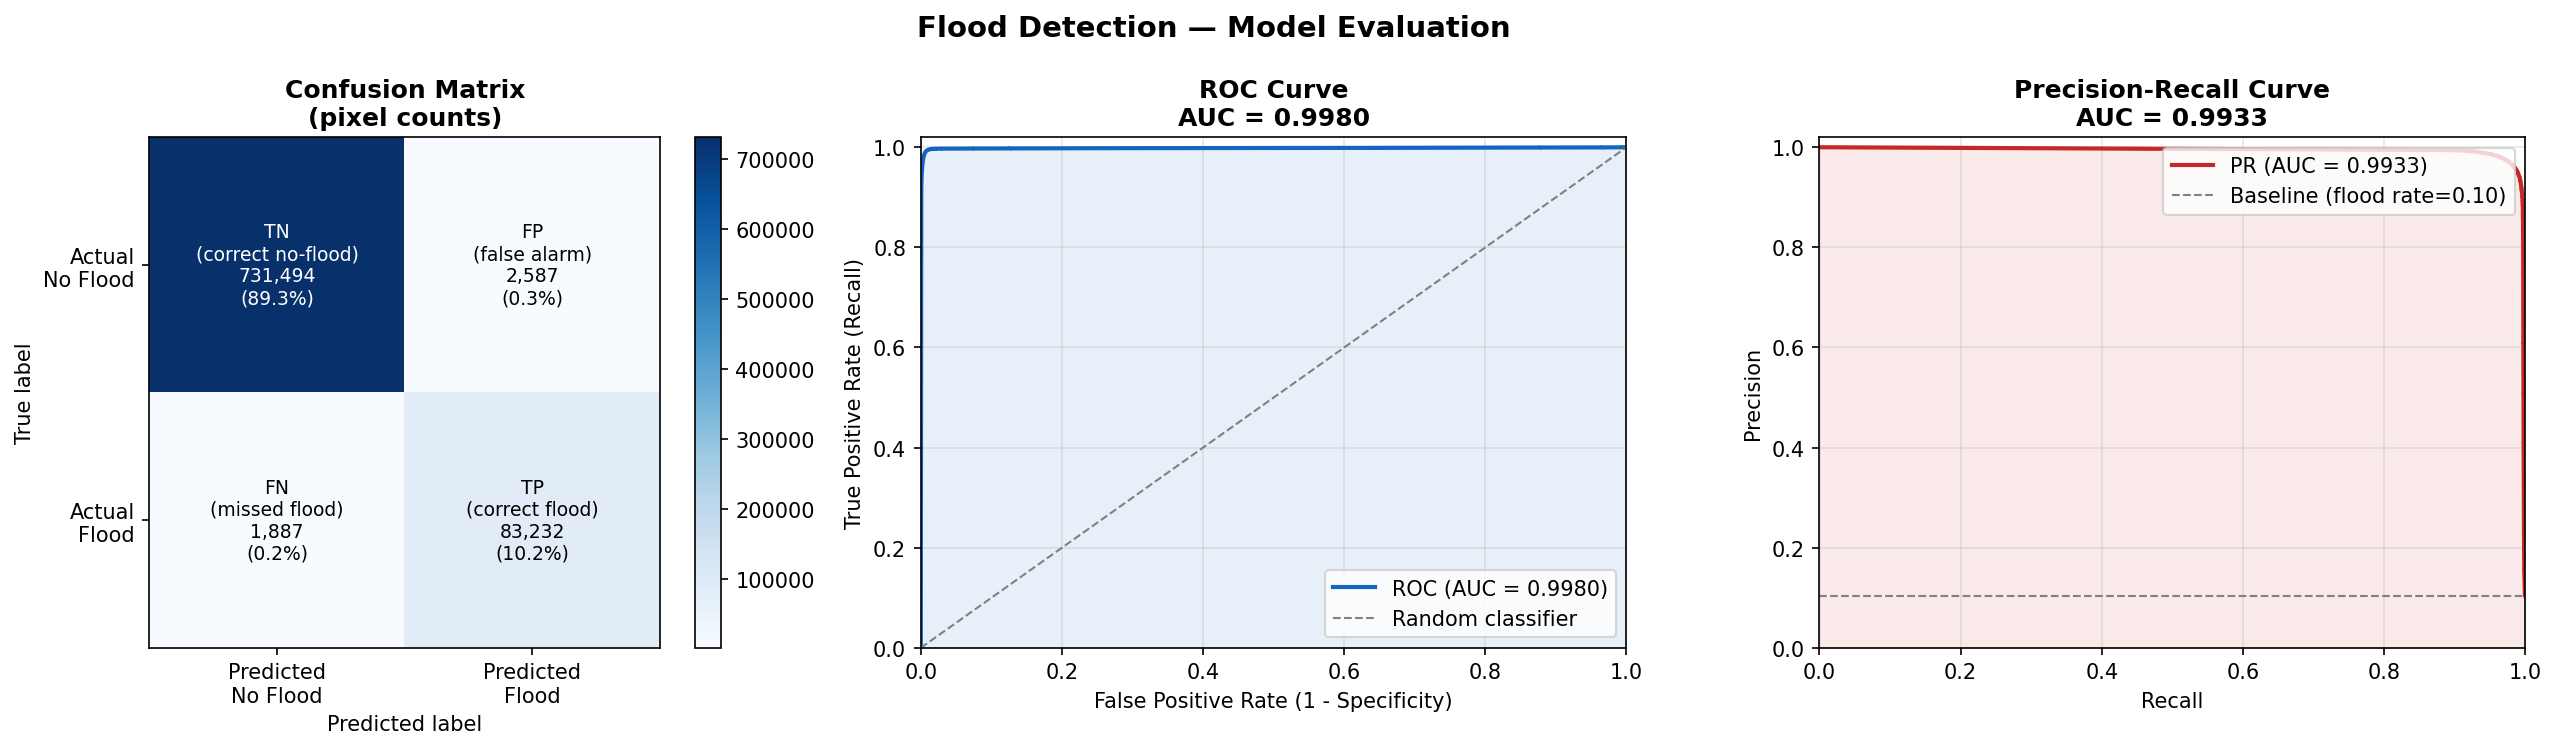

In [21]:
from IPython.display import Image as IPImage
IPImage(os.path.join(DRIVE_BASE,'evaluation','confusion_matrix_and_curves.png'))

## Cell 14 — List everything saved to Drive
Shows all files that were saved during this session.

In [22]:
print(f'Files saved to Google Drive ({DRIVE_BASE}/):\n')
for root,dirs,files in os.walk(DRIVE_BASE):
    dirs.sort(); files.sort()
    level = root.replace(DRIVE_BASE,'').count(os.sep)
    indent = '  '*level
    folder = os.path.basename(root)
    if level>0: print(f'{indent}📁 {folder}/')
    sub = '  '*(level+1)
    for f in files:
        fpath = os.path.join(root,f)
        size_kb = os.path.getsize(fpath)/1024
        print(f'{sub}📄 {f}  ({size_kb:.1f} KB)')

Files saved to Google Drive (/content/drive/MyDrive/FloodDetection/):

  📁 evaluation/
    📄 classification_report.txt  (0.7 KB)
    📄 confusion_matrix_and_curves.png  (158.1 KB)
    📄 metrics.json  (0.4 KB)
  📁 models/
    📄 flood_best.keras  (5929.4 KB)
    📄 flood_final.keras  (5929.4 KB)
    📄 training_history.png  (90.2 KB)
  📁 results/
    📄 chandpur_confluence.png  (103.3 KB)
    📄 kurigram_brahmaputra.png  (99.4 KB)
    📄 sirajganj_jamuna.png  (103.5 KB)
    📄 summary.json  (1.0 KB)
    📄 sunamganj_haor.png  (94.7 KB)
    📄 sylhet_surma_river.png  (94.6 KB)
  📁 satellite/
    📁 preview/
      📄 chandpur_confluence_dry_2024-03-30.png  (13.0 KB)
      📄 chandpur_confluence_monsoon_2024-09-28.png  (13.8 KB)
      📄 kurigram_brahmaputra_dry_2024-03-30.png  (13.2 KB)
      📄 kurigram_brahmaputra_monsoon_2024-09-28.png  (14.0 KB)
      📄 sirajganj_jamuna_dry_2024-03-30.png  (12.7 KB)
      📄 sirajganj_jamuna_monsoon_2024-09-28.png  (13.6 KB)
      📄 sunamganj_haor_dry_2024-03-30.png 